# European Option Pricing: The Black-Scholes Model

The Black-Scholes model provides a theoretical estimate of the price of European-style options. 
It assumes that the price of the underlying asset follows a geometric Brownian motion with constant drift and volatility. 
By using a self-financing replicating portfolio, the model derives a closed-form solution for the option's fair value and its sensitivities, known as the "Greeks."

In [4]:
from greeks import Greeks
from black_scholes import BlackScholes
import numpy as np
import matplotlib.pyplot as plt

In [24]:
params={"S":100,"K":150,"T":1.0,"r":0.05,"sigma": 0.2}
bs=BlackScholes(**params)
gr=Greeks(bs,kind="call")
call=bs.price('call')
put=bs.price('put')
print(f"Call Price: {call:.4f}")
print(f"Put Price: {put:.4f}")
print("Greeks Check:", gr.all_greeks())
print(f'Parity Check: {np.isclose(call-put,params['S']-params['K']*np.exp(-params['r']*params['T']))}')

Call Price: 0.3596
Put Price: 43.0440
Greeks Check: {'kind': 'call', 'Delta': np.float64(0.04673942041499812), 'Gamma': np.float64(0.0048860000728631805), 'Vega (1%)': np.float64(0.09772000145726362), 'Theta (1 day)': np.float64(-0.003268261987232823), 'Rho (1%)': np.float64(0.04314312215346886)}
Parity Check: True


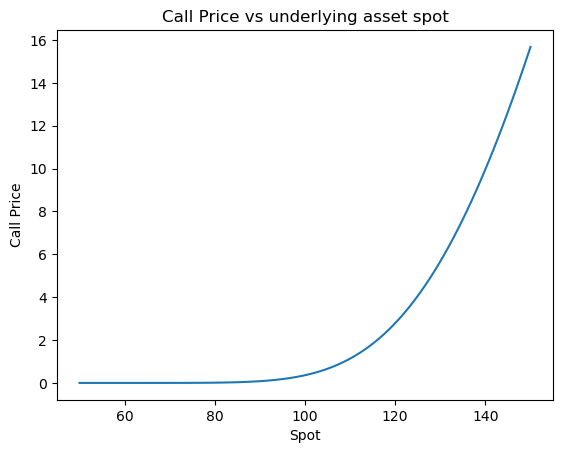

In [23]:
S_range=np.linspace(50,150,100)
call_price=[]
for S in S_range:
    param={"S":S,"K":150,"T":1.0,"r":0.05,"sigma": 0.2}
    bs=BlackScholes(**param)
    call=bs.price('call')
    call_price.append(call)
plt.plot(S_range,call_price)
plt.xlabel("Spot")
plt.ylabel("Call Price")
plt.title("Call Price vs underlying asset spot")
plt.show()

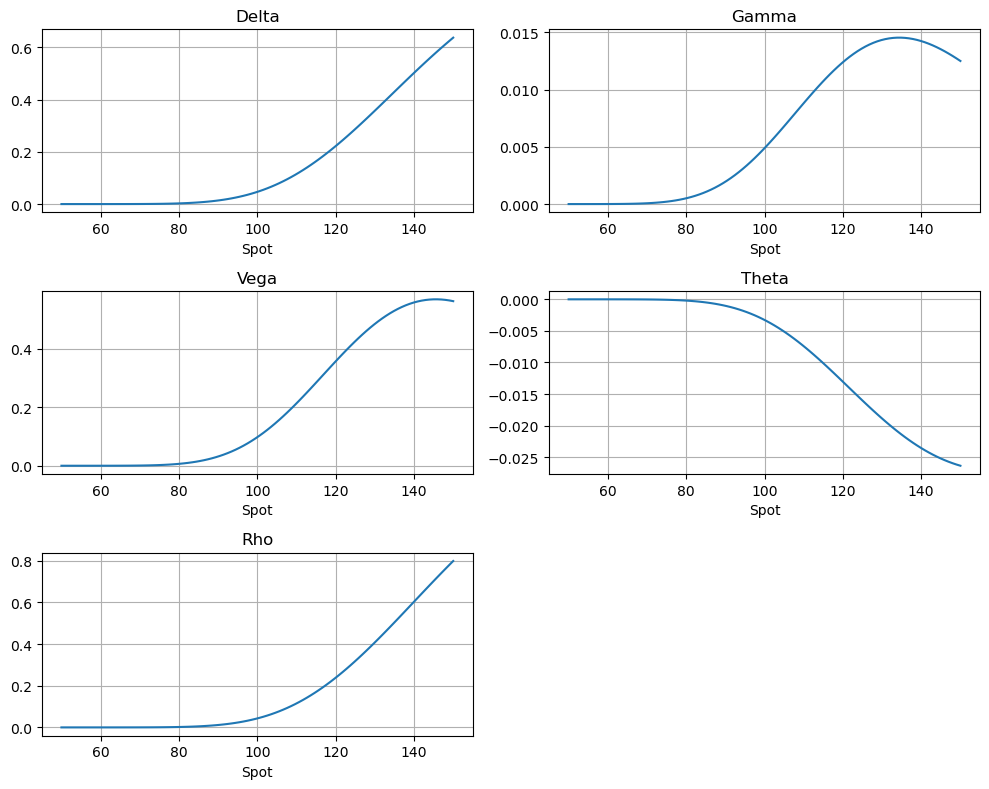

In [26]:
S_range=np.linspace(50,150,100)
delta=[]
gamma=[]
vega=[]
theta=[]
rho=[]
for S in S_range:
    param={"S": S, "K": 150, "T": 1.0, "r": 0.05, "sigma": 0.2}
    bs=BlackScholes(**param)
    gr=Greeks(bs,kind='call')
    g=gr.all_greeks()
    delta.append(g["Delta"])
    gamma.append(g["Gamma"])
    vega.append(g["Vega (1%)"])
    theta.append(g["Theta (1 day)"])
    rho.append(g["Rho (1%)"])
fig,axs=plt.subplots(3, 2, figsize=(10,8))
axs[0,0].plot(S_range, delta)
axs[0,0].set_title("Delta")
axs[0,1].plot(S_range, gamma)
axs[0,1].set_title("Gamma")
axs[1,0].plot(S_range, vega)
axs[1,0].set_title("Vega")
axs[1,1].plot(S_range, theta)
axs[1,1].set_title("Theta")
axs[2,0].plot(S_range, rho)
axs[2,0].set_title("Rho")
fig.delaxes(axs[2, 1])
for ax in axs.flat:
    ax.set_xlabel("Spot")
    ax.grid()
plt.tight_layout()
plt.show()